In [1]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(4096, 10))

In [2]:
X=torch.rand(1,1,224,224)
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape\t',X.shape)

Conv2d output shape	 torch.Size([1, 96, 54, 54])
ReLU output shape	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape	 torch.Size([1, 96, 26, 26])
Conv2d output shape	 torch.Size([1, 256, 26, 26])
ReLU output shape	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape	 torch.Size([1, 256, 12, 12])
Conv2d output shape	 torch.Size([1, 384, 12, 12])
ReLU output shape	 torch.Size([1, 384, 12, 12])
Conv2d output shape	 torch.Size([1, 384, 12, 12])
ReLU output shape	 torch.Size([1, 384, 12, 12])
Conv2d output shape	 torch.Size([1, 256, 12, 12])
ReLU output shape	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape	 torch.Size([1, 256, 5, 5])
Flatten output shape	 torch.Size([1, 6400])
Linear output shape	 torch.Size([1, 4096])
ReLU output shape	 torch.Size([1, 4096])
Dropout output shape	 torch.Size([1, 4096])
Linear output shape	 torch.Size([1, 4096])
ReLU output shape	 torch.Size([1, 4096])
Dropout output shape	 torch.Size([1, 4096])
Linear output shape	 torch.Size([1, 10])


In [3]:
#AlexNet在Fashion-MNIST数据集上的表现
batch_size=128
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size=batch_size,resize=224)

In [ ]:
def evaluate_accuracy_gpu(net,data_iter,device=None):
    if isinstance(net,torch.nn.Module):
        net.eval()
        if not device:
            device=next(iter(net.parameters())).device
    metric=d2l.Accumulator(2)
    for X,y in data_iter:
        if isinstance(X,list):
            X=[x.to(device) for x in X]
        else:
            X=X.to(device)
        y=y.to(device)
        metric.add(d2l.accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]

In [5]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weight(m):
        if type(m)==nn.Linear or type(m)==nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weight)
    print('training on', device)
    net.to(device)
    optimizer=torch.optim.AdamW(net.parameters(),lr=lr)
    loss=nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)

#训练循环
    for epoch in range(num_epochs):
        metric=d2l.Accumulator(5)
        net.train()
        for i,(X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X,y=X.to(device),y.to(device)
            y_hat=net(X)
            l=loss(y_hat,y)
            l.backward()
            optimizer.step()
            metric.add(l*X.shape[0],d2l.accuracy(y_hat,y),X.shape[0])
            timer.stop()
            train_l=metric[0]/metric[2]
            train_acc=metric[1]/metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc=evaluate_accuracy_gpu(net,test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.225, train acc 0.917, test acc 0.908
1602.4 examples/sec on cuda:0


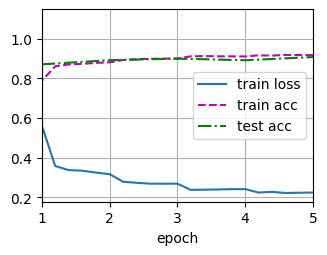

In [7]:
#评估AlexNet模型
lr,num_epochs=0.001,5
train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())